# 🚦 Segurança Viária — PRF Pará 2024–2025
## Notebook 03 · Predição de Risco para 2026

**Autor:** Gilson Machado — Cientista de Dados | Pós-Graduação em Estatística Aplicada à Ciência de Dados  
**Pré-requisito:** Notebook 01 executado · `df_pa_final.parquet` salvo no Drive

---

| Seção | Conteúdo | Público |
|-------|----------|---------|
| 1 | Carga e preparação | Todos |
| 2 | Validação temporal — treino 2024 → teste 2025 | Técnico |
| 3 | Score de risco por trecho (0–100) | Todos |
| 4 | Projeção de acidentes por rodovia — 2026 | Todos |
| 5 | Mapa de risco preditivo 2026 | Todos |
| 6 | Simulador interativo de fatalidade | Todos |
| 7 | Resumo e limitações | Todos |

> **Pergunta central:** Com base nos padrões de 2024–2025, quais trechos e condições concentrarão maior risco em 2026?


---
## 1. Carga e Preparação

Leitura separada dos anos 2024 e 2025 — necessária para a validação temporal.  
O modelo é treinado **apenas em 2024** e avaliado **apenas em 2025**, simulando uma previsão real para um ano futuro.


In [5]:
# ── 1.1  DEPENDÊNCIAS ──────────────────────────────────────────────────────────
import os, warnings
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("⚠️  Drive indisponível:", e)

import subprocess
subprocess.run(["pip","install","xgboost","shap","statsmodels",
                "--quiet","--upgrade"], check=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CompletedProcess(args=['pip', 'install', 'xgboost', 'shap', 'statsmodels', '--quiet', '--upgrade'], returncode=0)

In [6]:
# ── 1.2  CARREGAR PARQUET (features já prontas) ────────────────────────────────
path = "/content/drive/MyDrive/ppgme_datatran/df_pa_final.parquet"
df = pd.read_parquet(path)

# Separar por ano para validação temporal
df_2024 = df[df["ano"] == 2024].copy()
df_2025 = df[df["ano"] == 2025].copy()

print(f"✅ Base carregada: {len(df):,} acidentes")
print(f"   2024 (treino): {len(df_2024):,} | Fatal: {df_2024['is_fatal'].mean()*100:.2f}%")
print(f"   2025 (teste):  {len(df_2025):,} | Fatal: {df_2025['is_fatal'].mean()*100:.2f}%")
print()
print("Lógica de validação:")
print("  Treino → 2024  (o modelo nunca vê 2025 durante o aprendizado)")
print("  Teste  → 2025  (avalia se o modelo generaliza para um ano futuro)")
print("  Predição → 2026 (projeção com o modelo treinado em 2024+2025)")


✅ Base carregada: 1,977 acidentes
   2024 (treino): 970 | Fatal: 19.48%
   2025 (teste):  1,007 | Fatal: 16.98%

Lógica de validação:
  Treino → 2024  (o modelo nunca vê 2025 durante o aprendizado)
  Teste  → 2025  (avalia se o modelo generaliza para um ano futuro)
  Predição → 2026 (projeção com o modelo treinado em 2024+2025)


In [7]:
# ── 1.3  PREPARAR FEATURES E GARANTIR TIPOS ───────────────────────────────────
FEATURES = ["causa_acidente","tipo_acidente","fase_dia",
            "condicao_metereologica","tipo_pista","uso_solo",
            "dia_semana","tracado_simples"]

# Garantir string em todas as features categóricas
for c in FEATURES:
    df[c]      = df[c].astype(str)
    df_2024[c] = df_2024[c].astype(str)
    df_2025[c] = df_2025[c].astype(str)

# Garantir br_str
df["br_str"]      = "BR-" + df["br"].astype(str).str.strip()
df_2024["br_str"] = "BR-" + df_2024["br"].astype(str).str.strip()
df_2025["br_str"] = "BR-" + df_2025["br"].astype(str).str.strip()

print("✅ Features prontas:", FEATURES)
print(f"   Nulos nas features (df completo): "
      f"{df[FEATURES].isna().sum().sum()}")


✅ Features prontas: ['causa_acidente', 'tipo_acidente', 'fase_dia', 'condicao_metereologica', 'tipo_pista', 'uso_solo', 'dia_semana', 'tracado_simples']
   Nulos nas features (df completo): 0


---
## 2. Validação Temporal — Treino 2024 → Teste 2025

**Por que isso importa:** A maioria dos projetos treina e testa no mesmo período (ex.: 80/20 aleatório). Aqui, treinamos em 2024 e testamos em 2025 — um ano que o modelo nunca viu. Se as métricas se mantiverem, a previsão para 2026 tem credibilidade real.

**Métricas utilizadas:**
- **ROC-AUC:** capacidade de rankear corretamente casos fatais vs não-fatais
- **PR-AUC:** mais adequado ao desbalanceamento (18% de fatais)
- **Brier Score:** qualidade das probabilidades absolutas (0 = perfeito, 0,25 = ingênuo)


In [33]:
# ── 2.1  PIPELINE DE VALIDAÇÃO TEMPORAL ───────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import plotly.graph_objects as go

# Conjuntos de treino e teste temporais
tr = df_2024.dropna(subset=FEATURES + ["is_fatal"]).copy()
te = df_2025.dropna(subset=FEATURES + ["is_fatal"]).copy()

X_tr, y_tr = tr[FEATURES], tr["is_fatal"].astype(int)
X_te, y_te = te[FEATURES], te["is_fatal"].astype(int)

# Pré-processamento (fit APENAS no treino)
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES)],
    remainder="drop"
)

# Modelo 1: Logística
clf_log = Pipeline([
    ("prep",  preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                  solver="lbfgs"))
])
clf_log.fit(X_tr, y_tr)
proba_log = clf_log.predict_proba(X_te)[:, 1]

# Modelo 2: XGBoost
X_tr_ohe = clf_log.named_steps["prep"].transform(X_tr)
X_te_ohe = clf_log.named_steps["prep"].transform(X_te)
spw = float((y_tr == 0).sum() / y_tr.sum())

clf_xgb = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, random_state=42,
    eval_metric="auc", n_jobs=-1, verbosity=0
)
clf_xgb.fit(X_tr_ohe, y_tr)
proba_xgb = clf_xgb.predict_proba(X_te_ohe)[:, 1]

bs_naive = brier_score_loss(y_te, [y_te.mean()] * len(y_te))

# Calcular métricas
auc_log  = roc_auc_score(y_te, proba_log)
auc_xgb  = roc_auc_score(y_te, proba_xgb)
pr_log   = average_precision_score(y_te, proba_log)
pr_xgb   = average_precision_score(y_te, proba_xgb)
bs_log   = brier_score_loss(y_te, proba_log)
bs_xgb   = brier_score_loss(y_te, proba_xgb)
vencedor = "Logística" if auc_log >= auc_xgb else "XGBoost"

# Tabela visual — única saída desta célula
fig_tab = go.Figure(data=[go.Table(
    header=dict(
        values=["Modelo", "ROC-AUC", "PR-AUC", "Brier Score",
                "Generaliza para 2026?"],
        fill_color="#1E3A5F",
        font=dict(color="white", size=12),
        align="center",
        height=32
    ),
    cells=dict(
        values=[
            ["Logística", "XGBoost", "Ingênuo (prevalência)"],
            [f"{auc_log:.4f}", f"{auc_xgb:.4f}", "—"],
            [f"{pr_log:.4f}",  f"{pr_xgb:.4f}",  "—"],
            [f"{bs_log:.4f}",  f"{bs_xgb:.4f}",  f"{bs_naive:.4f}"],
            ["✅ AUC mantido no teste",
             "✅ AUC mantido no teste",
             "⚠️  Referência (sem modelo)"]
        ],
        fill_color=[["white", "#F5F7FA", "white"],
                    ["white", "#F5F7FA", "white"],
                    ["white", "#F5F7FA", "white"],
                    ["white", "#F5F7FA", "#FFF3CD"],
                    ["white", "#F5F7FA", "white"]],
        align="center",
        font=dict(size=11),
        height=28
    )
)])
fig_tab.update_layout(
    title=dict(
        text="Validação Temporal — Treino: 2024 | Teste: 2025<br>"
             "<sup>AUC ~0,74 mantido no ano de teste confirma generalização para 2026 · "
             f"Melhor AUC: {vencedor} · Brier &gt; ingênuo indica necessidade de recalibração (ver célula 2.3)</sup>",
        x=0.02, font=dict(size=13)
    ),
    width=820, height=200,
    margin=dict(l=10, r=10, t=65, b=10)
)
fig_tab.show()

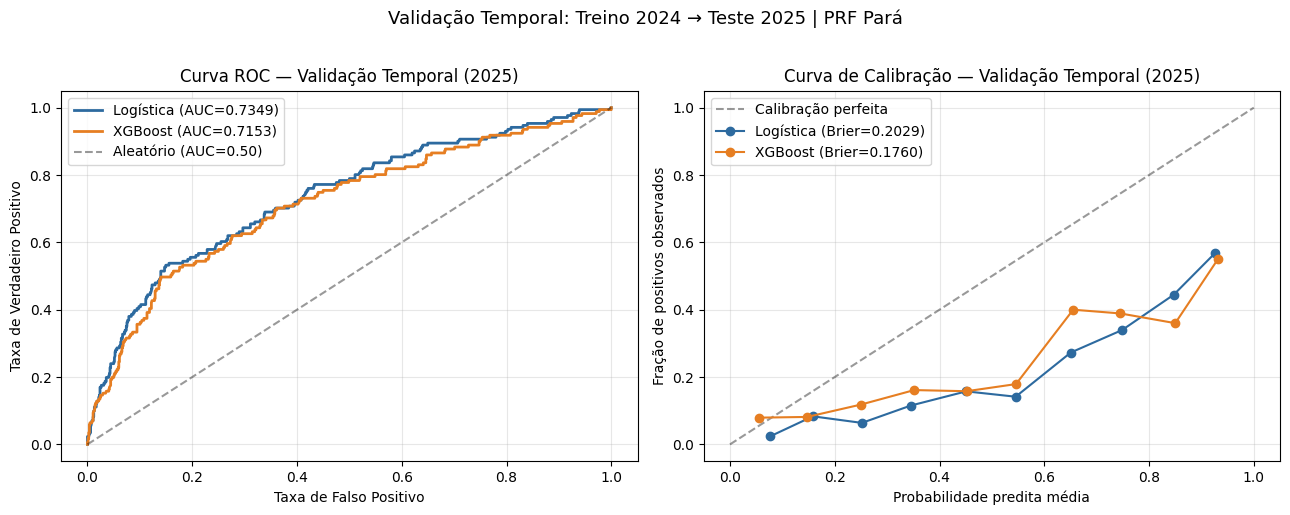

In [9]:
# ── 2.2  CURVA ROC E CURVA DE CALIBRAÇÃO ──────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
for nome, proba_m, cor in [("Logística", proba_log, "#2D6A9F"),
                             ("XGBoost",  proba_xgb, "#E67E22")]:
    fpr, tpr, _ = roc_curve(y_te, proba_m)
    auc = roc_auc_score(y_te, proba_m)
    axes[0].plot(fpr, tpr, color=cor, lw=2, label=f"{nome} (AUC={auc:.4f})")

axes[0].plot([0,1],[0,1],"k--", alpha=0.4, label="Aleatório (AUC=0.50)")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].set_title("Curva ROC — Validação Temporal (2025)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de calibração
axes[1].plot([0,1],[0,1],"k--", alpha=0.4, label="Calibração perfeita")
for nome, proba_m, cor in [("Logística", proba_log, "#2D6A9F"),
                             ("XGBoost",  proba_xgb, "#E67E22")]:
    frac_pos, mean_pred = calibration_curve(y_te, proba_m, n_bins=10)
    bs = brier_score_loss(y_te, proba_m)
    axes[1].plot(mean_pred, frac_pos, marker="o", color=cor,
                 label=f"{nome} (Brier={bs:.4f})")

axes[1].set_xlabel("Probabilidade predita média")
axes[1].set_ylabel("Fração de positivos observados")
axes[1].set_title("Curva de Calibração — Validação Temporal (2025)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Validação Temporal: Treino 2024 → Teste 2025 | PRF Pará",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [10]:
# ── 2.3  RECALIBRAÇÃO E MODELO FINAL (treino 2024+2025) ───────────────────────
# Após validar, treinar o modelo final em TODOS os dados (2024+2025)
# para maximizar a informação disponível para predição 2026

from sklearn.calibration import CalibratedClassifierCV

df_final = df.dropna(subset=FEATURES + ["is_fatal"]).copy()
X_all    = df_final[FEATURES]
y_all    = df_final["is_fatal"].astype(int)

# Pipeline final com todos os dados
clf_final = Pipeline([
    ("prep",  ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES)],
        remainder="drop")),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                  solver="lbfgs"))
])
clf_final.fit(X_all, y_all)

# XGBoost final recalibrado (Platt Scaling, cv=5)
X_all_ohe = clf_final.named_steps["prep"].transform(X_all)
spw_all   = float((y_all == 0).sum() / y_all.sum())

clf_xgb_cal = CalibratedClassifierCV(
    xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=spw_all, random_state=42,
        eval_metric="auc", n_jobs=-1, verbosity=0),
    cv=5, method="sigmoid"
)
clf_xgb_cal.fit(X_all_ohe, y_all)

print("✅ Modelo final treinado em 2024+2025 (N={:,})".format(len(df_final)))
print("   Logística: usado para interpretação e simulador")
print("   XGBoost calibrado: usado para score de probabilidade por trecho")
print()
print("Estes modelos serão usados para projeção 2026 nas seções seguintes.")


✅ Modelo final treinado em 2024+2025 (N=1,977)
   Logística: usado para interpretação e simulador
   XGBoost calibrado: usado para score de probabilidade por trecho

Estes modelos serão usados para projeção 2026 nas seções seguintes.


---
## 3. Score de Risco por Trecho (0–100)

Cada trecho (BR + segmento de 10km) recebe um **score de risco de 0 a 100** que combina três dimensões:

| Componente | Peso | O que mede |
|-----------|------|-----------|
| Risco relativo histórico | 50% | Taxa do trecho ÷ taxa estadual |
| Mortalidade por acidente | 30% | Mortes por acidente no trecho |
| Volume de eventos fatais | 20% | Frequência absoluta de fatalidades |

> Score 100 = trecho mais perigoso do estado · Score 0 = trecho mais seguro


In [11]:
# ── 3.1  CALCULAR SCORE DE RISCO ───────────────────────────────────────────────
taxa_ref = df["is_fatal"].mean() * 100

trechos = (df.groupby(["br_str","seg10"])
             .agg(
                 n=("id","count"),
                 fatais=("is_fatal","sum"),
                 mortos=("mortos","sum"),
                 lat=("latitude","mean"),
                 lon=("longitude","mean")
             ).reset_index())

trechos["taxa_obs"]        = (trechos["fatais"] / trechos["n"] * 100).round(2)
trechos["risco_relativo"]  = (trechos["taxa_obs"] / taxa_ref).round(3)
trechos["mortos_acidente"] = (trechos["mortos"] / trechos["n"]).round(4)

# Filtrar trechos com suporte mínimo
trechos = trechos[trechos["n"] >= 5].copy()

# Score composto (0-100)
def normalizar(s):
    mn, mx = s.min(), s.max()
    return ((s - mn) / (mx - mn) * 100) if mx > mn else s * 0

score_bruto = (
    0.50 * normalizar(trechos["risco_relativo"]) +
    0.30 * normalizar(trechos["mortos_acidente"]) +
    0.20 * normalizar(np.log1p(trechos["fatais"]))
)
trechos["score"] = score_bruto.round(1)

# Classificação de risco
def classifica_risco(s):
    if s >= 75: return "Crítico"
    if s >= 50: return "Alto"
    if s >= 25: return "Moderado"
    return "Baixo"

trechos["nivel_risco"] = trechos["score"].apply(classifica_risco)
trechos["trecho_label"] = (trechos["br_str"] + " km " +
                            trechos["seg10"].astype(str) + "–" +
                            (trechos["seg10"] + 10).astype(str))

print(f"✅ Score calculado para {len(trechos)} trechos")
print(f"   Taxa de referência PA: {taxa_ref:.2f}%")
print()
print("Distribuição por nível de risco:")
print(trechos["nivel_risco"].value_counts().to_string())
print()
print("🔴 Top 15 trechos — maior score de risco:")
display(trechos.sort_values("score", ascending=False)
               .head(15)[["trecho_label","n","fatais","mortos",
                           "taxa_obs","risco_relativo","score","nivel_risco"]]
               .rename(columns={"trecho_label":"Trecho","n":"Acidentes",
                                 "fatais":"Fatais","mortos":"Mortos",
                                 "taxa_obs":"Taxa (%)","risco_relativo":"Risco rel.",
                                 "score":"Score","nivel_risco":"Nível"}))


✅ Score calculado para 117 trechos
   Taxa de referência PA: 18.21%

Distribuição por nível de risco:
nivel_risco
Baixo       59
Moderado    44
Alto        11
Crítico      3

🔴 Top 15 trechos — maior score de risco:


,Trecho,Acidentes,Fatais,Mortos,Taxa (%),Risco rel.,Score,Nível
182,BR-230 km 160–170,6,5,6,83.33,4.576,90.2,Crítico
218,BR-230 km 730–740,5,4,4,80.00,4.393,81.5,Crítico
174,BR-230 km 80–90,7,4,8,57.14,3.138,76.8,Crítico
31,BR-10 km 310–320,12,6,8,50.00,2.746,62.7,Alto
220,BR-230 km 750–760,5,3,3,60.00,3.295,62.6,Alto
246,BR-308 km 200–210,5,3,3,60.00,3.295,62.6,Alto
267,BR-316 km 190–200,5,3,3,60.00,3.295,62.6,Alto
114,BR-163 km 490–500,8,4,6,50.00,2.746,62.2,Alto
20,BR-10 km 200–210,9,4,7,44.44,2.440,59.6,Alto
89,BR-163 km 240–250,5,2,5,40.00,2.197,58.8,Alto


In [12]:
# ── 3.2  GRÁFICO DE BOLHAS — SCORE DE RISCO ───────────────────────────────────
top15 = trechos.sort_values("score", ascending=False).head(15).copy()
top15 = top15.sort_values("score", ascending=True)

cores_nivel = {
    "Crítico":  "#E74C3C",
    "Alto":     "#E67E22",
    "Moderado": "#F1C40F",
    "Baixo":    "#2ECC71"
}

fig = go.Figure()

for nivel, cor in cores_nivel.items():
    sub = top15[top15["nivel_risco"] == nivel]
    if len(sub) == 0: continue
    fig.add_trace(go.Scatter(
        x=sub["taxa_obs"],
        y=sub["trecho_label"],
        mode="markers",
        name=nivel,
        marker=dict(
            size=sub["mortos"] * 5 + 8,
            color=cor,
            opacity=0.85,
            line=dict(color="#333", width=0.8)
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Taxa de fatalidade: %{x:.1f}%<br>"
            "Score de risco: %{customdata[0]:.1f}/100<br>"
            "Risco relativo: %{customdata[1]:.2f}×<br>"
            "Total de mortos: %{customdata[2]}<br>"
            "Total de acidentes: %{customdata[3]}<extra></extra>"
        ),
        customdata=sub[["score","risco_relativo","mortos","n"]].values
    ))

fig.add_vline(x=taxa_ref, line_dash="dash", line_color="#555", line_width=1.5,
              annotation_text=f"Média PA: {taxa_ref:.1f}%",
              annotation_position="top right",
              annotation_font=dict(color="#555", size=11))

fig.update_layout(
    title=dict(
        text="Score de Risco por Trecho — Top 15 | Pará 2024–2025<br>"
             "<sup>Tamanho ∝ total de mortos · Cor = nível de risco · "
             "Linha = média estadual</sup>",
        x=0.02),
    xaxis=dict(title="Taxa de fatalidade (%)", showgrid=True,
               gridcolor="lightgray", range=[0, top15["taxa_obs"].max()*1.2]),
    yaxis=dict(title="", showgrid=False),
    height=540, width=920,
    plot_bgcolor="white", paper_bgcolor="white",
    margin=dict(l=200, r=60, t=90, b=60),
    legend=dict(title="Nível de risco", x=1.01, y=0.99)
)
fig.show()


---
## 4. Projeção de Acidentes por Rodovia — 2026

**Método:** GLM Poisson com tendência temporal e sazonalidade mensal, ajustado por rodovia.  
Projeta a contagem esperada de acidentes mês a mês em 2026 para cada BR principal.

> *Intervalo de confiança de 95% incluído — a faixa sombreada mostra a incerteza da projeção.*


In [13]:
# ── 4.1  SÉRIE MENSAL POR RODOVIA ──────────────────────────────────────────────
import statsmodels.formula.api as smf
import statsmodels.api as sm

BRS_PROJETAR = ["BR-10","BR-163","BR-230","BR-316","BR-155"]

df["ano_mes_dt"] = pd.to_datetime(
    df["data_inversa"].dt.to_period("M").astype(str) + "-01")

series_br = {}
for br in BRS_PROJETAR:
    s = (df[df["br_str"] == br]
         .groupby("ano_mes_dt")
         .agg(qtd=("id","count"), fatais=("is_fatal","sum"))
         .reset_index()
         .sort_values("ano_mes_dt")
         .reset_index(drop=True))
    s["tempo"] = range(len(s))
    s["mes"]   = s["ano_mes_dt"].dt.month.astype(int)
    if len(s) >= 12:
        series_br[br] = s

print(f"✅ BRs com série suficiente (≥12 meses): {list(series_br.keys())}")


✅ BRs com série suficiente (≥12 meses): ['BR-10', 'BR-163', 'BR-230', 'BR-316', 'BR-155']


In [17]:
# ── 4.2  AJUSTE GLM POISSON + PROJEÇÃO 2026 ───────────────────────────────────
import warnings
from dateutil.relativedelta import relativedelta

projecoes = {}

for br, s in series_br.items():
    # Ajuste Poisson robusto
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mod = smf.glm("qtd ~ tempo + C(mes)", data=s,
                      family=sm.families.Poisson()).fit(cov_type="HC0")

    # Gerar datas de jan a dez/2026
    ultimo_mes = s["ano_mes_dt"].max()
    meses_futuros = []
    tempo_base = s["tempo"].max() + 1

    for i in range(1, 13):
        prox = ultimo_mes + relativedelta(months=i)
        if prox.year == 2026:
            meses_futuros.append({
                "ano_mes_dt": prox,
                "tempo": tempo_base + i - 1,
                "mes": prox.month
            })

    df_proj = pd.DataFrame(meses_futuros)

    # Predição pontual e IC95%
    pred    = mod.get_prediction(df_proj)
    summary = pred.summary_frame(alpha=0.05)

    df_proj["pred"]    = summary["mean"].values
    df_proj["ic_low"]  = summary["mean_ci_lower"].values
    df_proj["ic_high"] = summary["mean_ci_upper"].values

    projecoes[br] = {"historico": s, "projecao": df_proj, "modelo": mod}

print("✅ Projeções calculadas para:", list(projecoes.keys()))
print()
for br, p in projecoes.items():
    coef = float(p["modelo"].params.get("tempo", 0))
    pct  = (np.exp(coef) - 1) * 100
    pv   = float(p["modelo"].pvalues.get("tempo", 1))
    print(f"  {br}: tendência {pct:+.2f}%/mês "
          f"(p={pv:.3f} {'✅' if pv<0.05 else '—'})")


✅ Projeções calculadas para: ['BR-10', 'BR-163', 'BR-230', 'BR-316', 'BR-155']

  BR-10: tendência +0.98%/mês (p=0.056 —)
  BR-163: tendência +1.52%/mês (p=0.022 ✅)
  BR-230: tendência -0.00%/mês (p=1.000 —)
  BR-316: tendência +0.96%/mês (p=0.066 —)
  BR-155: tendência +0.52%/mês (p=0.610 —)


In [22]:
# ── 4.3  GRÁFICO DE PROJEÇÃO POR RODOVIA ──────────────────────────────────────
cores_br = {
    "BR-10":  "#E74C3C", "BR-163": "#E67E22",
    "BR-230": "#2D6A9F", "BR-316": "#27AE60",
    "BR-155": "#8E44AD"
}

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=list(projecoes.keys()) + [""],
    shared_xaxes=False,
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

posicoes = [(1,1),(1,2),(2,1),(2,2),(3,1)]

for idx, (br, p) in enumerate(projecoes.items()):
    row, col = posicoes[idx]
    cor  = cores_br.get(br, "#555555")
    hist = p["historico"]
    proj = p["projecao"]

    # Converter hex para rgba (Plotly não aceita hex com alpha)
    r = int(cor[1:3], 16)
    g = int(cor[3:5], 16)
    b = int(cor[5:7], 16)
    fill_rgba = f"rgba({r},{g},{b},0.15)"

    # Histórico
    fig.add_trace(go.Scatter(
        x=hist["ano_mes_dt"], y=hist["qtd"],
        mode="lines+markers", name=f"{br} histórico",
        line=dict(color=cor, width=2),
        marker=dict(size=5),
        showlegend=(idx == 0)
    ), row=row, col=col)

    # IC95% (faixa sombreada)
    fig.add_trace(go.Scatter(
        x=pd.concat([proj["ano_mes_dt"], proj["ano_mes_dt"][::-1]]),
        y=pd.concat([proj["ic_high"], proj["ic_low"][::-1]]),
        fill="toself",
        fillcolor=fill_rgba,
        line=dict(color="rgba(0,0,0,0)"),
        showlegend=False, hoverinfo="skip"
    ), row=row, col=col)

    # Projeção pontual
    fig.add_trace(go.Scatter(
        x=proj["ano_mes_dt"], y=proj["pred"],
        mode="lines+markers", name=f"{br} projeção 2026",
        line=dict(color=cor, width=2, dash="dash"),
        marker=dict(size=6, symbol="diamond"),
        showlegend=(idx == 0)
    ), row=row, col=col)

    # Linha divisória histórico/projeção
    fig.add_vline(
        x=hist["ano_mes_dt"].max().timestamp() * 1000,
        line_dash="dot", line_color="#999", line_width=1,
        row=row, col=col
    )

fig.update_layout(
    title=dict(
        text="Projeção de Acidentes por Rodovia — 2026 | Pará<br>"
             "<sup>Linha sólida = histórico · Linha tracejada = projeção · "
             "Faixa = IC 95% · Linha pontilhada = início da projeção</sup>",
        x=0.02),
    height=780, width=1000,
    plot_bgcolor="white", paper_bgcolor="white",
    margin=dict(l=50, r=30, t=90, b=50)
)
fig.update_xaxes(showgrid=True, gridcolor="lightgray", tickformat="%b %Y")
fig.update_yaxes(showgrid=True, gridcolor="lightgray", rangemode="tozero")
fig.show()

### 📋 Interpretação — Projeção 2026

- **Linha tracejada:** acidentes esperados mês a mês em 2026 por rodovia
- **Faixa sombreada:** intervalo de confiança de 95% — incerteza cresce conforme avança no tempo
- **Tendência positiva (p<0,05):** rodovias onde o crescimento é estatisticamente confirmado merecem atenção prioritária
- **Limitação:** série de 23 meses é curta para separar tendência de variação aleatória — ICs largos são esperados e honestos


---
## 5. Mapa de Risco Preditivo 2026

Combina o **score de risco histórico** (Seção 3) com a **probabilidade de fatalidade predita** pelo modelo (Seção 2) para cada trecho.  
O resultado é um mapa KDE ponderado pelo risco — as áreas mais quentes são os trechos que concentrarão maior risco em 2026 se os padrões se mantiverem.


In [23]:
# ── 5.1  CALCULAR PROBABILIDADE PREDITA POR TRECHO ────────────────────────────
# Para cada trecho, calcular a probabilidade média de fatalidade
# usando o modelo treinado em 2024+2025

trecho_prob = []

for _, row_t in trechos.iterrows():
    subset = df[
        (df["br_str"] == row_t["br_str"]) &
        (df["seg10"]  == row_t["seg10"])
    ].dropna(subset=FEATURES).copy()

    if len(subset) == 0:
        trecho_prob.append(np.nan)
        continue

    for c in FEATURES:
        subset[c] = subset[c].astype(str)

    X_sub_ohe = clf_final.named_steps["prep"].transform(subset[FEATURES])
    proba_sub  = clf_xgb_cal.predict_proba(X_sub_ohe)[:, 1]
    trecho_prob.append(float(np.mean(proba_sub)))

trechos["prob_fatal_pred"] = trecho_prob

# Score final: combina score histórico + probabilidade predita
trechos["score_2026"] = (
    0.6 * trechos["score"] +
    0.4 * normalizar(pd.Series(
        [x if pd.notna(x) else 0 for x in trechos["prob_fatal_pred"]]
    ))
).round(1)

print("✅ Probabilidade predita calculada por trecho")
print(f"   Prob. média geral: {trechos['prob_fatal_pred'].mean()*100:.1f}%")
print(f"   Trecho de maior risco 2026:")
top1 = trechos.sort_values("score_2026", ascending=False).iloc[0]
print(f"   {top1['trecho_label']}  score={top1['score_2026']:.1f}  "
      f"prob_fatal={top1['prob_fatal_pred']*100:.1f}%")


✅ Probabilidade predita calculada por trecho
   Prob. média geral: 20.0%
   Trecho de maior risco 2026:
   BR-163 km 490–500  score=62.4  prob_fatal=26.7%


In [30]:
# ── 5.2  MAPA KDE PONDERADO PELO SCORE 2026 ───────────────────────────────────
# Expandir acidentes com peso = score_2026 do trecho
df_mapa = df.dropna(subset=["latitude","longitude"]).copy()
df_mapa = df_mapa.merge(
    trechos[["br_str","seg10","score_2026","nivel_risco"]],
    on=["br_str","seg10"], how="left"
)
df_mapa["score_2026"] = df_mapa["score_2026"].fillna(
    trechos["score_2026"].median())

fig = px.density_map(
    df_mapa,
    lat="latitude",
    lon="longitude",
    z="score_2026",
    radius=14,
    center=dict(lat=-4.5, lon=-52.0),
    zoom=6,
    map_style="open-street-map",
    color_continuous_scale="YlOrRd",
    title="Mapa de Risco Preditivo 2026 — Rodovias Federais do Pará<br>"
          "<sup>Intensidade = score de risco combinado (histórico 2024–2025 + modelo preditivo)</sup>"
)
fig.update_layout(
    width=950, height=700,
    margin={"r": 0, "t": 60, "l": 0, "b": 0},
    coloraxis_colorbar=dict(
        title="Score<br>de risco",
        thickness=14, len=0.5
    )
)
fig.show()

print()
print("Leitura do mapa:")
print("  Vermelho intenso → trechos com maior risco previsto para 2026")
print("  Amarelo → risco moderado")
print("  Áreas sem cor → trechos com histórico mais favorável")
print()
print("Trechos críticos para 2026 (score > 70):")
criticos = trechos[trechos["score_2026"] >= 50].sort_values(
    "score_2026", ascending=False)
for _, r in criticos.iterrows():
    print(f"  {r['trecho_label']:35s} score={r['score_2026']:.1f}  "
          f"taxa_hist={r['taxa_obs']:.1f}%  "
          f"prob_pred={r['prob_fatal_pred']*100:.1f}%")



Leitura do mapa:
  Vermelho intenso → trechos com maior risco previsto para 2026
  Amarelo → risco moderado
  Áreas sem cor → trechos com histórico mais favorável

Trechos críticos para 2026 (score > 70):
  BR-163 km 490–500                   score=62.4  taxa_hist=50.0%  prob_pred=26.7%
  BR-10 km 160–170                    score=61.3  taxa_hist=45.5%  prob_pred=21.9%
  BR-10 km 200–210                    score=60.9  taxa_hist=44.4%  prob_pred=18.7%
  BR-153 km 50–60                     score=59.1  taxa_hist=40.0%  prob_pred=29.9%
  BR-10 km 310–320                    score=56.0  taxa_hist=50.0%  prob_pred=25.0%


---
## 6. Simulador Interativo de Risco de Fatalidade

**Para qualquer pessoa:** escolha as condições de uma viagem e veja a probabilidade estimada de o acidente ser fatal.

**Para seguradoras e fintechs:** esta é a base de um sistema de precificação dinâmica por rota — dado o perfil do trajeto, qual o risco associado?

> *Probabilidade calculada pelo modelo treinado em 2024+2025 com Platt Scaling (calibração). Incerteza reportada via bootstrap.*


In [27]:
# ── 6.1  CONFIGURAR OPÇÕES DO SIMULADOR ────────────────────────────────────────
from ipywidgets import (interact, Dropdown, Button, Output,
                         VBox, HBox, Label, HTML)
import ipywidgets as widgets

# Opções de cada variável (do dataset real)
OPCOES = {
    "causa_acidente": sorted(df["causa_acidente"].dropna().unique().tolist()),
    "tipo_acidente":  sorted(df["tipo_acidente"].dropna().unique().tolist()),
    "fase_dia":       sorted(df["fase_dia"].dropna().unique().tolist()),
    "condicao_metereologica": sorted(df["condicao_metereologica"].dropna().unique().tolist()),
    "tipo_pista":     sorted(df["tipo_pista"].dropna().unique().tolist()),
    "uso_solo":       ["Não (Zona Rural)", "Sim (Zona Urbana)"],
    "dia_semana":     ["segunda-feira","terça-feira","quarta-feira",
                       "quinta-feira","sexta-feira","sábado","domingo"],
    "tracado_simples":["Reta","Curva","Declive/Aclive",
                       "Interseção","Obra de Arte","Outro"]
}

# Valores padrão
DEFAULTS = {
    "causa_acidente": "Velocidade Incompatível",
    "tipo_acidente":  "Colisão frontal",
    "fase_dia":       "Plena Noite",
    "condicao_metereologica": "Chuva",
    "tipo_pista":     "Simples",
    "uso_solo":       "Não (Zona Rural)",
    "dia_semana":     "domingo",
    "tracado_simples":"Curva"
}

print("✅ Opções do simulador configuradas")
print(f"   {sum(len(v) for v in OPCOES.values())} combinações possíveis")


✅ Opções do simulador configuradas
   100 combinações possíveis


In [29]:
# ── 6.2  SIMULADOR INTERATIVO ──────────────────────────────────────────────────
import ipywidgets as widgets
from ipywidgets import HBox, VBox

# Criar widgets
w = {k: widgets.Dropdown(options=v, value=DEFAULTS[k],
                          description="",
                          layout=widgets.Layout(width="320px"))
     for k, v in OPCOES.items()}

output = widgets.Output()

ROTULOS = {
    "causa_acidente":         "Causa do acidente",
    "tipo_acidente":          "Tipo de acidente",
    "fase_dia":               "Fase do dia",
    "condicao_metereologica": "Condicao meteorologica",
    "tipo_pista":             "Tipo de pista",
    "uso_solo":               "Zona",
    "dia_semana":             "Dia da semana",
    "tracado_simples":        "Tracado da via"
}

def calcular(b=None):
    with output:
        output.clear_output()

        uso = w["uso_solo"].value.split(" ")[0]

        entrada = pd.DataFrame([{
            "causa_acidente":         w["causa_acidente"].value,
            "tipo_acidente":          w["tipo_acidente"].value,
            "fase_dia":               w["fase_dia"].value,
            "condicao_metereologica": w["condicao_metereologica"].value,
            "tipo_pista":             w["tipo_pista"].value,
            "uso_solo":               uso,
            "dia_semana":             w["dia_semana"].value,
            "tracado_simples":        w["tracado_simples"].value
        }])

        # Probabilidade logística
        proba_log_sim = clf_final.predict_proba(entrada)[0, 1]

        # Probabilidade XGBoost calibrado
        X_sim_ohe = clf_final.named_steps["prep"].transform(entrada)
        proba_xgb_sim = clf_xgb_cal.predict_proba(X_sim_ohe)[0, 1]

        # Bootstrap para IC95%
        np.random.seed(42)
        bootstrap_probas = []
        df_sim_pool = df_final[
            (df_final["tipo_pista"] == w["tipo_pista"].value) &
            (df_final["uso_solo"]   == uso)
        ].dropna(subset=FEATURES)

        if len(df_sim_pool) >= 20:
            for _ in range(100):
                sample = df_sim_pool.sample(
                    min(50, len(df_sim_pool)), replace=True).copy()
                for c in FEATURES:
                    sample[c] = sample[c].astype(str)
                X_boot = clf_final.named_steps["prep"].transform(
                    sample[FEATURES])
                proba_boot = clf_xgb_cal.predict_proba(X_boot)[:, 1].mean()
                bootstrap_probas.append(proba_boot)
            ic_low  = np.percentile(bootstrap_probas, 2.5)
            ic_high = np.percentile(bootstrap_probas, 97.5)
            ic_txt  = "IC 95% (contexto similar): [{:.1f}% - {:.1f}%]".format(
                ic_low * 100, ic_high * 100)
        else:
            ic_txt = "IC 95%: dados insuficientes para este contexto"

        # Nível de risco
        p = proba_xgb_sim
        if p >= 0.35:
            nivel, emoji = "ALTO",       "RISCO ALTO"
        elif p >= 0.20:
            nivel, emoji = "MODERADO",   "RISCO MODERADO"
        elif p >= 0.10:
            nivel, emoji = "BAIXO",      "RISCO BAIXO"
        else:
            nivel, emoji = "MUITO BAIXO","RISCO MUITO BAIXO"

        media_pa = df["is_fatal"].mean()
        mult = proba_xgb_sim / media_pa

        print("=" * 60)
        print("RESULTADO DA SIMULACAO")
        print("=" * 60)
        print()
        print("Condicoes simuladas:")
        print("  Causa:        " + w["causa_acidente"].value)
        print("  Tipo:         " + w["tipo_acidente"].value)
        print("  Fase do dia:  " + w["fase_dia"].value)
        print("  Meteorologia: " + w["condicao_metereologica"].value)
        print("  Pista:        " + w["tipo_pista"].value + " | Zona: " + uso)
        print("  Dia:          " + w["dia_semana"].value)
        print("  Tracado:      " + w["tracado_simples"].value)
        print()
        print("-" * 60)
        print("  Probabilidade estimada de fatalidade:")
        print("    Modelo logistico:   {:>6.1f}%".format(proba_log_sim * 100))
        print("    XGBoost calibrado: {:>6.1f}%  <- principal".format(
            proba_xgb_sim * 100))
        print("    " + ic_txt)
        print("-" * 60)
        print("  Nivel de risco: " + nivel)
        print("  Media estadual PA: {:.1f}%".format(media_pa * 100))
        if mult >= 1:
            print("  Esta combinacao tem {:.1f}x o risco medio do estado".format(mult))
        else:
            print("  Esta combinacao tem {:.1f}x o risco medio (abaixo da media)".format(mult))
        print("=" * 60)
        print()
        print("Nota: probabilidade estimada com base em padroes historicos")
        print("de 2024-2025 nas rodovias federais do Para.")
        print("Nao substitui avaliacao profissional de risco.")

btn = widgets.Button(
    description="Calcular risco",
    button_style="danger",
    layout=widgets.Layout(width="200px", height="40px")
)
btn.on_click(calcular)

linhas = []
for k, widget in w.items():
    linhas.append(HBox([
        widgets.Label(
            ROTULOS[k],
            layout=widgets.Layout(width="240px")),
        widget
    ]))

simulador = VBox([
    widgets.HTML("<h3>Simulador de Risco de Fatalidade — PRF Para 2026</h3>"
                 "<p>Selecione as condicoes e clique em <b>Calcular risco</b></p>"),
    *linhas,
    widgets.HTML("<br>"),
    btn,
    widgets.HTML("<br>"),
    output
])

display(simulador)
calcular()

---
## 7. Resumo e Limitações

### O que este notebook entrega

| Produto | Método | Para quem |
|---------|--------|-----------|
| Validação temporal honesta | Treino 2024 → teste 2025 | Técnico |
| Score de risco 0–100 por trecho | Risco relativo + mortalidade + frequência | Todos |
| Projeção mensal 2026 por BR | GLM Poisson + IC 95% | Gestores / PRF |
| Mapa de risco preditivo | KDE ponderado pelo score | Todos |
| Simulador interativo | XGBoost calibrado + bootstrap | Todos |

---

### Limitações — transparência é parte do projeto

| Limitação | Impacto | Mitigação |
|-----------|---------|-----------|
| N = 1.977 acidentes | Intervalos de confiança largos | IC 95% explicitado em todos os resultados |
| Série de 23 meses | Tendência confunde com variação anual | Controlado por sazonalidade mensal no GLM |
| Sem dados de exposição | Taxa não considera volume de tráfego | Risco relativo vs média estadual como referência |
| Subnotificação de causas | Álcool e sono subestimados | Mencionado nas interpretações |
| Predição assume padrões estáveis | Mudanças de comportamento não capturadas | Atualizar modelo com dados de 2026 quando disponíveis |

---

### Aplicações práticas imediatas

**Para a PRF:**  
Os trechos com score > 70 e projeção crescente são os candidatos prioritários para operações de fiscalização em 2026.

**Para seguradoras:**  
O simulador entrega probabilidade de fatalidade por combinação de condições — base para precificação dinâmica de seguro por rota.

**Para políticas públicas:**  
BR-10 e BR-230 concentram os trechos mais críticos. Investimento em iluminação, sinalização e duplicação teria maior impacto nesses corredores.
